# Proyek Akhir PKK - Kelompok 14
## MODUL 1: DATA & ENVIRONMENT SETUP
Fokus Eksekusi: Membaca struktur teksnya, dan mengonversinya menjadi matriks 2D menggunakan NumPy. Memastikan koordinat titik awal (start) dan target (goal) terpetakan dengan benar dan tidak jatuh di atas area rintangan.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math
import random
import matplotlib.animation as animation  

from IPython.display import HTML

random.seed(42)
np.random.seed(42)

In [12]:
class EnvironmentManager:
    
    @staticmethod
    def load_moving_ai_map(filepath):
        if not os.path.exists(filepath):
            raise FileNotFoundError(f"File dataset tidak ditemukan di path: {filepath}")
            
        with open(filepath, 'r') as file:
            lines = file.readlines()
            
        height = int(lines[1].strip().split(' ')[1])
        width = int(lines[2].strip().split(' ')[1])
        print(f"[INFO] Dataset '{filepath}' berhasil dimuat. Ukuran grid: {height} baris x {width} kolom.")
        
        grid = []
        for line in lines[4:]:
            row = []
            for char in line.strip():
                # 0 = area yang bisa dilalui
                if char in ['.', 'G', 'S']:  
                    row.append(0)
                # 1 = rintangan/dinding
                else:
                    row.append(1)
            grid.append(row)
            
        return np.array(grid)

    @staticmethod
    def visualize_grid(grid, start_node, goal_node, title="Simulasi Ruangan (ACO)"):
        plt.figure(figsize=(8, 8))
        
        plt.imshow(grid, cmap='Greys', origin='upper')
        
        plt.scatter(start_node[1], start_node[0], c='blue', marker='o', s=150, edgecolors='white', label='Start')
        plt.scatter(goal_node[1], goal_node[0], c='lime', marker='*', s=250, edgecolors='black', label='Target / Goal')
        
        plt.title(title, fontsize=14, pad=15)
        plt.legend(loc='upper right')
        plt.grid(False)
        plt.show()
        
    @staticmethod
    def _setup_base_arena(ax, grid, start_node, goal_node, title):
        ax.imshow(grid, cmap='Greys', origin='upper')
        ax.scatter(start_node[1], start_node[0], c='blue', marker='o', s=150, edgecolors='white', label='Start', zorder=5)
        ax.scatter(goal_node[1], goal_node[0], c='lime', marker='*', s=250, edgecolors='black', label='Target', zorder=5)
        ax.set_title(title, fontsize=14, pad=15)
        ax.legend(loc='upper right')
        ax.grid(False)

    @staticmethod
    def visualize_best_route(grid, start_node, goal_node, best_path, title="Rute Terbaik ACO"):
        fig, ax = plt.subplots(figsize=(10, 10))
        
        EnvironmentManager._setup_base_arena(ax, grid, start_node, goal_node, title)
        
        # Plot koordinat X dan Y jalur terbaik
        if best_path:
            path_y = [pos[0] for pos in best_path]
            path_x = [pos[1] for pos in best_path]
            ax.plot(path_x, path_y, color='red', linewidth=2, label='Jalur Semut', alpha=0.8)
            
        plt.show()
        
    @staticmethod
    def plot_convergence(convergence_curve):
        plt.figure(figsize=(10, 5))
        clean_curve = [val if val != float('inf') else None for val in convergence_curve]
        
        plt.plot(clean_curve, marker='o', linestyle='-', color='b')
        plt.title('Grafik Konvergensi Jarak Ant Colony Optimization')
        plt.xlabel('Iterasi')
        plt.ylabel('Jarak Terpendek (Langkah)')
        plt.grid(True)
        plt.show()
        
    @staticmethod
    def animate_best_route(grid, start_node, goal_node, best_path, title="Rute Terbaik ACO"):
        fig, ax = plt.subplots(figsize=(10, 10))
        
        EnvironmentManager._setup_base_arena(ax, grid, start_node, goal_node, title)
        
        line, = ax.plot([], [], color='red', linewidth=3, alpha=0.8)
        ant_marker, = ax.plot([], [], marker='o', color='darkred', markersize=8, zorder=6)

        if not best_path:
            print("Tidak ada rute untuk dianimasikan.")
            plt.close()
            return None
            
        # Koordinat
        path_y = [pos[0] for pos in best_path]
        path_x = [pos[1] for pos in best_path]
        
        def init():
            line.set_data([], [])
            ant_marker.set_data([], [])
            return line, ant_marker
            
        def update(frame):
            line.set_data(path_x[:frame+1], path_y[:frame+1]) 
            ant_marker.set_data([path_x[frame]], [path_y[frame]]) 
            return line, ant_marker
            
        # Animasi (interval kecepatan)
        ani = animation.FuncAnimation(
            fig, update, frames=len(best_path), init_func=init,
            interval=100, blit=True, repeat=False
        )
        
        plt.close()
        return HTML(ani.to_jshtml())

[INFO] Dataset './dao-map/arena.map' berhasil dimuat. Ukuran grid: 49 baris x 49 kolom.


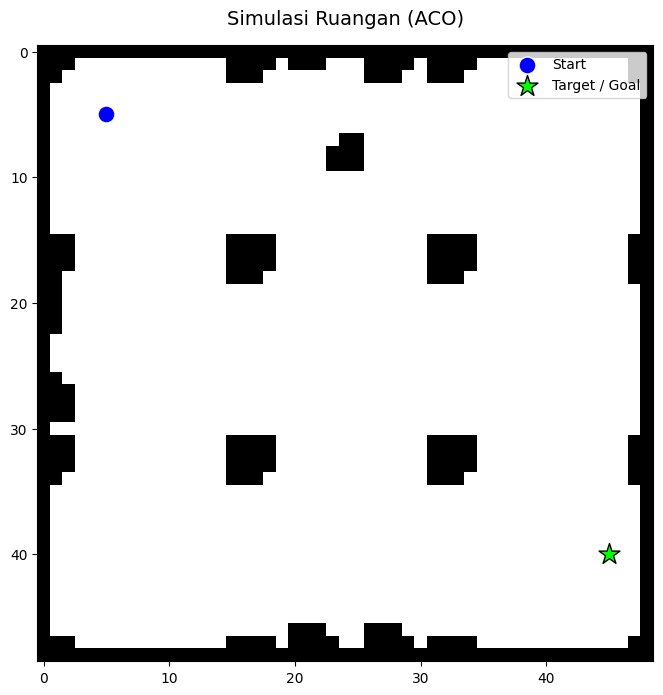

In [13]:
DATASET_FILE = r'./dao-map/arena.map' 

try:
    env_manager = EnvironmentManager()
    env_matrix = env_manager.load_moving_ai_map(DATASET_FILE)
    
    # Koordinat Start dan Target
    start_pos = (5, 5)   
    target_pos = (40, 45) 
    
    if env_matrix[start_pos[0], start_pos[1]] == 1:
        print("[PERINGATAN] Titik Start berada di dalam rintangan!")
    if env_matrix[target_pos[0], target_pos[1]] == 1:
        print("[PERINGATAN] Titik Target berada di dalam rintangan!")
        
    env_manager.visualize_grid(env_matrix, start_pos, target_pos)

except Exception as e:
    print(f"Terjadi kesalahan: {e}")

## Modul 2: Core Ant Logic Developer

In [14]:
class Ant:
    def __init__(self, start_pos, goal_pos, env_matrix, alpha=1.0, beta=1.0):
        self.start_pos = start_pos
        self.goal_pos = goal_pos
        self.current_pos = start_pos
        self.env_matrix = env_matrix
        self.alpha = alpha         
        self.beta = beta            
        self.path = [start_pos]
        self.is_stuck = False
        self.reached_goal = False
    
    def get_possible_moves(self):
        moves = []
        directions = [
            (-1, 0), (1, 0), (0, -1), (0, 1),
            (-1, -1), (-1, 1), (1, -1), (1, 1)
        ]

        for d in directions:
            new_r = self.current_pos[0] + d[0]
            new_c = self.current_pos[1] + d[1]

            if 0 <= new_r < self.env_matrix.shape[0] and 0 <= new_c < self.env_matrix.shape[1]:
                if self.env_matrix[new_r, new_c] == 0:
                    if (new_r, new_c) not in self.path:
                        moves.append((new_r, new_c))
        return moves

    def calculate_heuristic(self, next_pos):
        dy = next_pos[0] - self.goal_pos[0]
        dx = next_pos[1] - self.goal_pos[1]
        distance = math.sqrt(dx**2 + dy**2)

        if distance == 0:
            return float('inf')

        return 1.0 / distance

    def choose_next_node(self, possible_moves, pheromone_matrix):
        for move in possible_moves:
            if move == self.goal_pos:
                return move
            
        numerators = []
        for move in possible_moves:
            tau = pheromone_matrix[move[0], move[1]]
            eta = self.calculate_heuristic(move)
            
    def choose_next_node(self, possible_moves, pheromone_matrix):
        for move in possible_moves:
            if move == self.goal_pos:
                return move

        numerators = []
        for move in possible_moves:
            tau = pheromone_matrix[move[0], move[1]]
            eta = self.calculate_heuristic(move)
            # rumus ACO: 
            score = (tau ** self.alpha) * (eta ** self.beta)
            numerators.append(score)
            
        total_score = sum(numerators)
        if total_score == 0:
            return random.choice(possible_moves)
            
        # normalisasi
        probabilities = [score / total_score for score in numerators]
        
        # Roulette Wheel Selection
        rand_val = random.random()
        cumulative_prob = 0.0
        
        for i, move in enumerate(possible_moves):
            cumulative_prob += probabilities[i]
            if rand_val <= cumulative_prob:
                return move
        return possible_moves[-1]

    def step(self, pheromone_matrix):
        if self.current_pos == self.goal_pos:
            self.reached_goal = True
            return

        possible_moves = self.get_possible_moves()

        if not possible_moves:
            self.is_stuck = True   
            return

        next_pos = self.choose_next_node(possible_moves, pheromone_matrix)
        self.path.append(next_pos)
        self.current_pos = next_pos

# Test KOD

In [15]:
if __name__ == "__main__":
    dummy_env = np.zeros((10, 10))
    dummy_env[2:8, 4] = 1
    start = (1, 1)
    goal = (8, 8)
    dummy_pheromone = np.ones((10, 10))
    test_ant = Ant(start_pos=start, goal_pos=goal, env_matrix=dummy_env, alpha=1.0, beta=2.0)

    print("--- MEMULAI TES PERGERAKAN SEMUT ---")
    print(f"Posisi Awal   : {start}")
    print(f"Posisi Target : {goal}")
    print("Mulai berjalan...\n")
    
    step_count = 0
    max_steps = 100 
    
    while not test_ant.reached_goal and not test_ant.is_stuck and step_count < max_steps:
        test_ant.step(dummy_pheromone)
        step_count += 1
        print(f"Langkah {step_count}: Semut berpindah ke {test_ant.current_pos}")
        
    print("\n--- HASIL AKHIR ---")
    if test_ant.reached_goal:
        print(f"✅ SUKSES! Semut berhasil mencapai target dalam {step_count} langkah.")
        print(f"Jalur yang dilewati:\n{test_ant.path}")
    elif test_ant.is_stuck:
        print("❌ GAGAL! Semut terjebak di jalan buntu (Tabu list penuh / terhalang tembok).")
        print(f"Jalur terakhir sebelum terjebak:\n{test_ant.path}")
    else:
        print("⚠️ TIMEOUT! Semut berputar-putar terlalu lama dan mencapai batas maksimal langkah.")

--- MEMULAI TES PERGERAKAN SEMUT ---
Posisi Awal   : (1, 1)
Posisi Target : (8, 8)
Mulai berjalan...

Langkah 1: Semut berpindah ke (0, 2)
Langkah 2: Semut berpindah ke (1, 2)
Langkah 3: Semut berpindah ke (1, 3)
Langkah 4: Semut berpindah ke (2, 3)
Langkah 5: Semut berpindah ke (1, 4)
Langkah 6: Semut berpindah ke (0, 5)
Langkah 7: Semut berpindah ke (1, 6)
Langkah 8: Semut berpindah ke (0, 6)
Langkah 9: Semut berpindah ke (1, 5)
Langkah 10: Semut berpindah ke (2, 5)
Langkah 11: Semut berpindah ke (3, 5)
Langkah 12: Semut berpindah ke (2, 6)
Langkah 13: Semut berpindah ke (3, 6)
Langkah 14: Semut berpindah ke (4, 6)
Langkah 15: Semut berpindah ke (5, 5)
Langkah 16: Semut berpindah ke (5, 6)
Langkah 17: Semut berpindah ke (5, 7)
Langkah 18: Semut berpindah ke (6, 6)
Langkah 19: Semut berpindah ke (7, 7)
Langkah 20: Semut berpindah ke (8, 8)
Langkah 21: Semut berpindah ke (8, 8)

--- HASIL AKHIR ---
✅ SUKSES! Semut berhasil mencapai target dalam 21 langkah.
Jalur yang dilewati:
[(1, 1),

## Modul 3 : Pheromone & Iteration Manager
Fokus Eksekusi: Mengendalikan sistem Swarm Intelligence. Membangun loop algoritme utama untuk banyak semut dalam beberapa iterasi. Menerapkan persamaan matematis untuk menambahkan feromon pada jalur yang berhasil (deposition), serta menjalankan fungsi penguapan (evaporation) pada jalur lainnya agar simulasi konvergen ke rute paling optimal.

In [16]:
class AntColony:
    def __init__(self, env_matrix, start_pos, target_pos, num_ants=20, iterations=50, 
                evaporation_rate=0.1, Q=100, alpha=1.0, beta=2.0):
        
        self.env_matrix = env_matrix
        self.start_pos = start_pos
        self.target_pos = target_pos
        
        # Hyperparameter ACO
        self.num_ants = num_ants
        self.iterations = iterations
        self.evaporation_rate = evaporation_rate
        self.Q = Q
        self.alpha = alpha
        self.beta = beta
        self.pheromone_matrix = np.ones(env_matrix.shape) * 0.1 
        self.global_best_path = None
        self.global_best_length = float('inf')
        
    def run(self):
        print("[INFO] Memulai Simulasi Ant Colony Optimization...")
        
        convergence_curve = []
        
        for it in range(self.iterations):
            successful_paths = []
            
            for _ in range(self.num_ants):
                ant = Ant(self.start_pos, self.target_pos, self.env_matrix, self.alpha, self.beta)
                
                step_count = 0
                while not ant.reached_goal and not ant.is_stuck and step_count < 1000:
                    ant.step(self.pheromone_matrix)
                    step_count += 1
                
                if ant.reached_goal:
                    successful_paths.append(ant.path)
                    
                    # Cek Jalur Terbaik
                    if len(ant.path) < self.global_best_length:
                        self.global_best_length = len(ant.path)
                        self.global_best_path = ant.path
            
            # Update Feromon
            self.update_pheromones(successful_paths)
            
            print(f"Iterasi {it+1}/{self.iterations} | Semut Sukses: {len(successful_paths)} | Jarak Terbaik Sementara: {self.global_best_length}")
            
            convergence_curve.append(self.global_best_length)
            
        return self.global_best_path, self.global_best_length, convergence_curve

    def update_pheromones(self, successful_paths):
        # Evaporation
        self.pheromone_matrix *= (1.0 - self.evaporation_rate)
        
        # Deposition
        for path in successful_paths:
            L = len(path)
            delta_tau = self.Q / L
            
            for (r, c) in path:
                self.pheromone_matrix[r, c] += delta_tau

## Tuning

In [17]:
# Auto Tuning (Grid Search)
print("Mulai proses pencarian parameter terbaik...\n")

DATASET_FILE = r'./dao-map/arena.map' 
env_manager = EnvironmentManager()
env_matrix = env_manager.load_moving_ai_map(DATASET_FILE)

start_pos = (5, 5)   
target_pos = (40, 45)

daftar_alpha = [1.0, 3.0]
daftar_beta = [1.0, 4.0]
daftar_evaporation = [0.1, 0.5]

rekor_global_jarak = float('inf')
parameter_terbaik = {}

for a in daftar_alpha:
    for b in daftar_beta:
        for rho in daftar_evaporation:
            print(f"Mencari - Alpha: {a} | Beta: {b} | Evaporation: {rho}")
            
            colony = AntColony(
                env_matrix=env_matrix, start_pos=start_pos, target_pos=target_pos, 
                num_ants=15, iterations=25, evaporation_rate=rho, Q=100, alpha=a, beta=b
            )
            
            best_path, best_length, convergence_curve = colony.run()
            
            if best_length < rekor_global_jarak:
                rekor_global_jarak = best_length
                parameter_terbaik = {'alpha': a, 'beta': b, 'evaporation_rate': rho}
                
                rute_paling_optimal = best_path
                jarak_optimal = best_length
                history_paling_optimal = convergence_curve

print(f"\nPencarian selesai. Parameter terbaik: {parameter_terbaik}")

Mulai proses pencarian parameter terbaik...

[INFO] Dataset './dao-map/arena.map' berhasil dimuat. Ukuran grid: 49 baris x 49 kolom.
Mencari - Alpha: 1.0 | Beta: 1.0 | Evaporation: 0.1
[INFO] Memulai Simulasi Ant Colony Optimization...
Iterasi 1/25 | Semut Sukses: 0 | Jarak Terbaik Sementara: inf
Iterasi 2/25 | Semut Sukses: 0 | Jarak Terbaik Sementara: inf
Iterasi 3/25 | Semut Sukses: 0 | Jarak Terbaik Sementara: inf
Iterasi 4/25 | Semut Sukses: 0 | Jarak Terbaik Sementara: inf
Iterasi 5/25 | Semut Sukses: 0 | Jarak Terbaik Sementara: inf
Iterasi 6/25 | Semut Sukses: 0 | Jarak Terbaik Sementara: inf
Iterasi 7/25 | Semut Sukses: 0 | Jarak Terbaik Sementara: inf
Iterasi 8/25 | Semut Sukses: 1 | Jarak Terbaik Sementara: 205
Iterasi 9/25 | Semut Sukses: 1 | Jarak Terbaik Sementara: 205
Iterasi 10/25 | Semut Sukses: 0 | Jarak Terbaik Sementara: 205
Iterasi 11/25 | Semut Sukses: 1 | Jarak Terbaik Sementara: 195
Iterasi 12/25 | Semut Sukses: 0 | Jarak Terbaik Sementara: 195
Iterasi 13/25 | S

In [18]:
# Perbandingan log default vs optimal

print("Simulasi default (sebelum tuning)")
print("Parameter: Alpha=1.0, Beta=1.0, Evaporation=0.1\n")

colony_default = AntColony(
    env_matrix=env_matrix, start_pos=start_pos, target_pos=target_pos, 
    num_ants=20, iterations=40, evaporation_rate=0.1, Q=100, alpha=1.0, beta=1.0
)
_, jarak_default, _ = colony_default.run()


print("\nSimulasi optimal (sesudah tuning)")
print(f"Parameter: Alpha={parameter_terbaik['alpha']}, Beta={parameter_terbaik['beta']}, Evaporation={parameter_terbaik['evaporation_rate']}\n")

print("Ringkasan perbandingan:")
print(f"Jarak default: {jarak_default} langkah")
print(f"Jarak optimal: {jarak_optimal} langkah")

Simulasi default (sebelum tuning)
Parameter: Alpha=1.0, Beta=1.0, Evaporation=0.1

[INFO] Memulai Simulasi Ant Colony Optimization...
Iterasi 1/40 | Semut Sukses: 0 | Jarak Terbaik Sementara: inf
Iterasi 2/40 | Semut Sukses: 0 | Jarak Terbaik Sementara: inf
Iterasi 3/40 | Semut Sukses: 0 | Jarak Terbaik Sementara: inf
Iterasi 4/40 | Semut Sukses: 0 | Jarak Terbaik Sementara: inf
Iterasi 5/40 | Semut Sukses: 1 | Jarak Terbaik Sementara: 167
Iterasi 6/40 | Semut Sukses: 4 | Jarak Terbaik Sementara: 167
Iterasi 7/40 | Semut Sukses: 1 | Jarak Terbaik Sementara: 167
Iterasi 8/40 | Semut Sukses: 1 | Jarak Terbaik Sementara: 167
Iterasi 9/40 | Semut Sukses: 2 | Jarak Terbaik Sementara: 167
Iterasi 10/40 | Semut Sukses: 0 | Jarak Terbaik Sementara: 167
Iterasi 11/40 | Semut Sukses: 0 | Jarak Terbaik Sementara: 167
Iterasi 12/40 | Semut Sukses: 1 | Jarak Terbaik Sementara: 167
Iterasi 13/40 | Semut Sukses: 1 | Jarak Terbaik Sementara: 167
Iterasi 14/40 | Semut Sukses: 1 | Jarak Terbaik Sementar

Menampilkan visualisasi dari hasil optimal...

Grafik konvergensi:


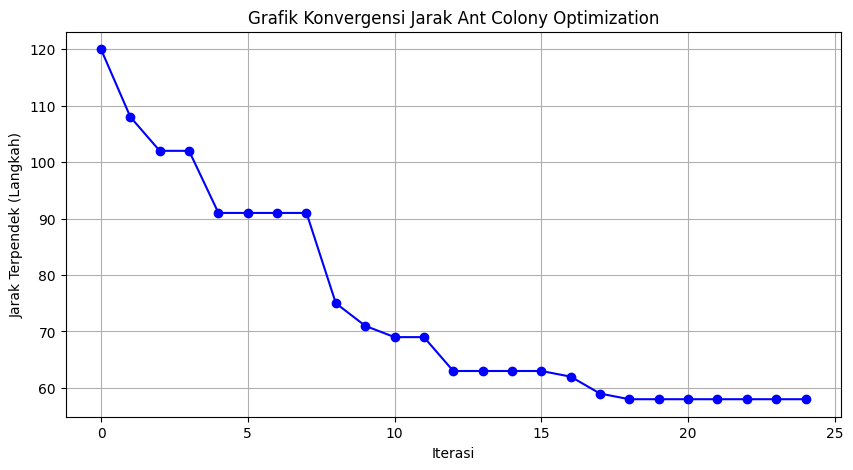

Animasi rute terpendek:


In [19]:
# Convergensi dan Animasi Rute Terbaik
from IPython.display import display

print("Menampilkan visualisasi dari hasil optimal...\n")

if rute_paling_optimal:
    print("Grafik konvergensi:")
    env_manager.plot_convergence(history_paling_optimal)
    
    print("Animasi rute terpendek:")
    animasi_html = env_manager.animate_best_route(env_matrix, start_pos, target_pos, rute_paling_optimal)
    if animasi_html is not None:
        display(animasi_html)
else:
    print("Tidak ada rute optimal yang berhasil divisualisasikan.")